# STS RAG Evaluation Analysis

Notebook nay phan tich output tu `src/rag/sts_eval.py`, so sanh hai cot RAG output voi cot reference `response`:

- `qwen + RAG with vietnamese-sbert`
- `qwen + RAG with halong_embedding`

Mac dinh notebook doc file `data/processed/legal_valid_sts_eval.json`. Neu file nay chua co, hay chay script STS eval truoc.

In [31]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_colwidth", 220)

SBERT_FIELD = "qwen + RAG with vietnamese-sbert"
HALONG_FIELD = "qwen + RAG with halong_embedding"

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src" / "rag" / "sts_eval.py").exists():
            return candidate
    return current

ROOT = find_repo_root()
EVAL_PATH = ROOT / "data" / "processed" / "legal_valid_sts_eval.json"
REPORT_DIR = ROOT / "data" / "processed" / "sts_eval_report"

print(f"Repo root: {ROOT}")
print(f"Eval file: {EVAL_PATH}")

Repo root: D:\dl\dl
Eval file: D:\dl\dl\data\processed\legal_valid_sts_eval.json


## Load Ket Qua STS

Neu cell nay bao thieu file, chay lenh sau o terminal tu repo root:

```bash
python src/rag/sts_eval.py --input data/processed/legal_valid.json --output data/processed/legal_valid_sts_eval.json
```

In [32]:
if not EVAL_PATH.exists():
    raise FileNotFoundError(
        f"Khong tim thay {EVAL_PATH}. Hay chay src/rag/sts_eval.py truoc khi mo notebook nay."
    )

with EVAL_PATH.open("r", encoding="utf-8") as f:
    result = json.load(f)

items = result.get("items", [])
print(f"Model STS: {result.get('model')}")
print(f"Input path: {result.get('input_path')}")
print(f"So mau: {len(items)}")

Model STS: keepitreal/vietnamese-sbert
Input path: data\processed\legal_valid.json
So mau: 200


In [33]:
rows = []
for item in items:
    scores = item.get("sts_vs_response", {})
    sbert_score = scores.get(SBERT_FIELD, np.nan)
    halong_score = scores.get(HALONG_FIELD, np.nan)
    rows.append(
        {
            "index": item.get("index"),
            "instruction": item.get("instruction", ""),
            "response": item.get("response", ""),
            "sbert_answer": item.get(SBERT_FIELD, ""),
            "halong_answer": item.get(HALONG_FIELD, ""),
            "sts_sbert": sbert_score,
            "sts_halong": halong_score,
            "delta_halong_minus_sbert": halong_score - sbert_score,
            "response_len": len(str(item.get("response", ""))),
            "sbert_len": len(str(item.get(SBERT_FIELD, ""))),
            "halong_len": len(str(item.get(HALONG_FIELD, ""))),
        }
    )

df = pd.DataFrame(rows)
df["min_sts"] = df[["sts_sbert", "sts_halong"]].min(axis=1)
df["max_sts"] = df[["sts_sbert", "sts_halong"]].max(axis=1)
df["abs_delta"] = df["delta_halong_minus_sbert"].abs()

display(df.head())

,index,instruction,response,sbert_answer,halong_answer,sts_sbert,sts_halong,delta_halong_minus_sbert,response_len,sbert_len,halong_len,min_sts,max_sts,abs_delta
0,1,"Theo Điều 5 Luật Địa chất và Khoáng sản, hội nhập và hợp tác quốc tế về địa chất, khoáng sản được thực hiện trong những hoạt động cụ thể nào?","Theo Khoản 1 Điều 5 Luật Địa chất và Khoáng sản, hội nhập và hợp tác quốc tế về địa chất, khoáng sản được thực hiện trong các hoạt động sau: nghiên cứu, điều tra cơ bản địa chất; điều tra địa chất về khoáng sản; hoạt...","Kết luận ngắn:\nTheo Điều 5 của Luật Địa chất và Khoáng sản 2024 (Số hiệu: 54/2024/QH15), hội nhập và hợp tác quốc tế về địa chất, khoáng sản được thực hiện trong các hoạt động như nghiên cứu, điều tra cơ bản địa chấ...","Kết luận ngắn:\nTheo Điều 5 của Luật Địa chất và Khoáng sản 2024 (Số hiệu: 54/2024/QH15), hội nhập và hợp tác quốc tế về địa chất, khoáng sản được thực hiện trong các hoạt động cụ thể như nghiên cứu, điều tra cơ bản ...",0.824213,0.897401,0.073188,266,671,478,0.824213,0.897401,0.073188
1,2,"Theo Điều 5 của Luật, khi thực hiện hội nhập và hợp tác quốc tế về địa chất, khoáng sản, Việt Nam cần tuân thủ những nguyên tắc và khuôn khổ pháp lý nào?","Khi thực hiện hội nhập và hợp tác quốc tế về địa chất, khoáng sản, Việt Nam cần tuân thủ một số nguyên tắc và khuôn khổ pháp lý quan trọng. Cụ thể, Khoản 1 Điều 5 quy định việc này phải đặt trong tổng thể chiến lược ...","Kết luận ngắn:\nViệt Nam cần tuân thủ các nguyên tắc và khuôn khổ pháp lý như Hiến pháp, pháp luật Việt Nam, Hiến chương Liên hợp quốc, điều ước quốc tế mà Việt Nam là thành viên, bảo đảm phù hợp với đường lối và chí...","Kết luận ngắn:\nViệt Nam cần tuân thủ các nguyên tắc và khuôn khổ pháp lý cụ thể khi thực hiện hội nhập và hợp tác quốc tế về địa chất, khoáng sản.\n\nCăn cứ pháp lý:\nTheo Điều 5 của Luật Địa chất và Khoáng sản 2024...",0.801260,0.894713,0.093453,757,428,846,0.801260,0.894713,0.093453
2,3,"Giả sử có một tranh chấp quốc tế phát sinh liên quan đến địa chất, khoáng sản mà Việt Nam là một bên, việc giải quyết tranh chấp này sẽ được thực hiện theo nguyên tắc và cơ sở pháp lý nào theo Luật Địa chất và Khoáng...","Theo Khoản 2 Điều 5 Luật Địa chất và Khoáng sản, nếu có một tranh chấp quốc tế phát sinh liên quan đến địa chất, khoáng sản, việc giải quyết tranh chấp này sẽ được thực hiện thông qua các biện pháp hòa bình. Cơ sở ph...","Kết luận ngắn:\nViệc giải quyết tranh chấp quốc tế về địa chất, khoáng sản sẽ được thực hiện thông qua các biện pháp hòa bình, tuân thủ thông lệ quốc tế, pháp luật quốc tế và pháp luật của các bên liên quan theo quy ...","Kết luận ngắn:\nViệc giải quyết tranh chấp quốc tế phát sinh liên quan đến địa chất, khoáng sản giữa Việt Nam với các bên khác sẽ tuân thủ nguyên tắc hòa bình và thông lệ quốc tế.\n\nCăn cứ pháp lý:\nTheo Điều 5 của ...",0.904306,0.910479,0.006173,1120,1403,803,0.904306,0.910479,0.006173
3,4,"Theo Điều 2 của Luật Địa chất và Khoáng sản, ""Địa chất"" được định nghĩa như thế nào?","Dựa trên Khoản 1 Điều 2 của Luật Địa chất và Khoáng sản, ""Địa chất"" được hiểu là các dạng vật chất cấu tạo nên trái đất, các quá trình diễn ra trong tự nhiên phát sinh từ sự tiến hóa của trái đất cũng như địa hình, c...","Kết luận ngắn: \nĐịa chất được định nghĩa là các dạng vật chất cấu tạo nên trái đất, các quá trình diễn ra trong tự nhiên phát sinh từ sự tiến hóa của trái đất cũng như địa hình, cảnh quan, hiện tượng địa chất và môi...","Kết luận ngắn: \nĐịa chất được định nghĩa là các dạng vật chất cấu tạo nên trái đất, các quá trình diễn ra trong tự nhiên phát sinh từ sự tiến hóa của trái đất cũng như địa hình, cảnh quan, hiện tượng địa chất và môi...",0.935867,0.950870,0.015003,301,377,625,0.935867,0.950870,0.015003
4,5,"Hãy phân tích sự khác biệt và mối quan hệ giữa ""Di chỉ địa chất"" và ""Di sản địa chất"" theo quy định tại Điều 2 của Luật Địa chất và Khoáng sản.","Theo Khoản 6 Điều 2, ""Di chỉ địa chất"" là tập hợp các dấu hiệu, đặc điểm của hoạt động địa chất có giá trị nổi bật về khoa 

## Metric Tong Quan

In [34]:
def summarize_scores(values: pd.Series) -> dict[str, float]:
    values = values.dropna()
    return {
        "avg_similarity": values.mean(),
        "median_similarity": values.median(),
        "std_similarity": values.std(ddof=0),
        "percent_above_0.85": (values >= 0.85).mean(),
        "percent_above_0.70": (values >= 0.70).mean(),
        "percent_below_0.60": (values < 0.60).mean(),
    }

metrics_df = pd.DataFrame(
    {
        "vietnamese_sbert_rag": summarize_scores(df["sts_sbert"]),
        "halong_embedding_rag": summarize_scores(df["sts_halong"]),
    }
).T

display(metrics_df.style.format("{:.4f}"))

,avg_similarity,median_similarity,std_similarity,percent_above_0.85,percent_above_0.70,percent_below_0.60
vietnamese_sbert_rag,0.8652,0.8824,0.0759,0.6750,0.9700,0.0150
halong_embedding_rag,0.8775,0.8878,0.0615,0.7550,0.9850,0.0050


In [35]:
winner_counts = pd.Series(
    np.where(
        df["sts_halong"] > df["sts_sbert"],
        "halong_embedding cao hon",
        np.where(df["sts_halong"] < df["sts_sbert"], "vietnamese-sbert cao hon", "bang nhau"),
    ),
    name="winner",
).value_counts()

display(winner_counts.to_frame("count"))
print(f"Delta trung binh halong - sbert: {df['delta_halong_minus_sbert'].mean():.4f}")
print(f"Delta median halong - sbert: {df['delta_halong_minus_sbert'].median():.4f}")

,count
winner,
halong_embedding cao hon,105
vietnamese-sbert cao hon,88
bang nhau,7


Delta trung binh halong - sbert: 0.0123
Delta median halong - sbert: 0.0032


## Phan Phoi Diem STS

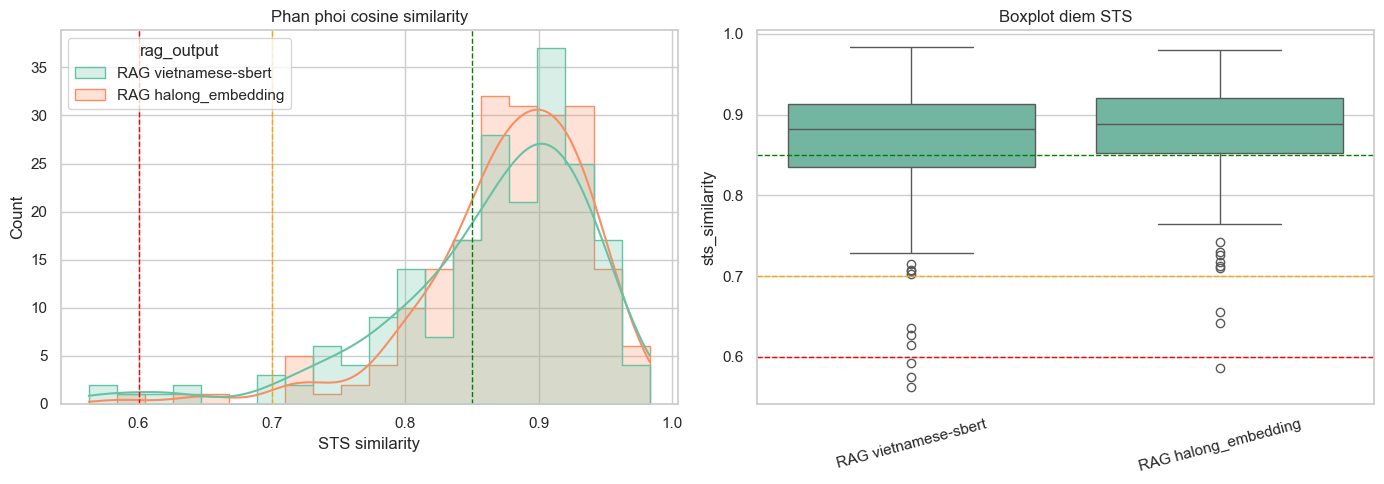

In [36]:
plot_df = df.melt(
    id_vars=["index"],
    value_vars=["sts_sbert", "sts_halong"],
    var_name="rag_output",
    value_name="sts_similarity",
)
plot_df["rag_output"] = plot_df["rag_output"].map(
    {"sts_sbert": "RAG vietnamese-sbert", "sts_halong": "RAG halong_embedding"}
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=plot_df,
    x="sts_similarity",
    hue="rag_output",
    bins=20,
    kde=True,
    element="step",
    ax=axes[0],
)
axes[0].axvline(0.85, color="green", linestyle="--", linewidth=1)
axes[0].axvline(0.70, color="orange", linestyle="--", linewidth=1)
axes[0].axvline(0.60, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Phan phoi cosine similarity")
axes[0].set_xlabel("STS similarity")

sns.boxplot(data=plot_df, x="rag_output", y="sts_similarity", ax=axes[1])
axes[1].axhline(0.85, color="green", linestyle="--", linewidth=1)
axes[1].axhline(0.70, color="orange", linestyle="--", linewidth=1)
axes[1].axhline(0.60, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Boxplot diem STS")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

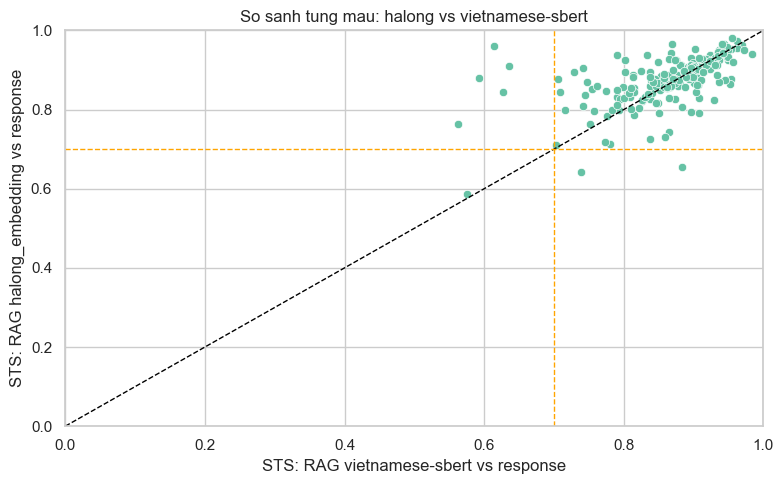

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="sts_sbert", y="sts_halong", ax=ax)
ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
ax.axvline(0.70, color="orange", linestyle="--", linewidth=1)
ax.axhline(0.70, color="orange", linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("So sanh tung mau: halong vs vietnamese-sbert")
ax.set_xlabel("STS: RAG vietnamese-sbert vs response")
ax.set_ylabel("STS: RAG halong_embedding vs response")
plt.tight_layout()
plt.show()

## Bucket Va Nhan Chat Luong

In [38]:
BUCKET_ORDER = ["<0.60", "0.60-0.70", "0.70-0.85", ">=0.85"]

def bucket_score(score: float) -> str:
    if pd.isna(score):
        return "missing"
    if score >= 0.85:
        return ">=0.85"
    if score >= 0.70:
        return "0.70-0.85"
    if score >= 0.60:
        return "0.60-0.70"
    return "<0.60"

def quality_label(score: float) -> str:
    if pd.isna(score):
        return "missing"
    if score >= 0.85:
        return "good"
    if score >= 0.70:
        return "acceptable"
    return "needs_review"

df["bucket_sbert"] = df["sts_sbert"].map(bucket_score)
df["bucket_halong"] = df["sts_halong"].map(bucket_score)
df["label_sbert"] = df["sts_sbert"].map(quality_label)
df["label_halong"] = df["sts_halong"].map(quality_label)

bucket_df = pd.concat(
    [
        df["bucket_sbert"].value_counts().reindex(BUCKET_ORDER, fill_value=0).rename("vietnamese_sbert_rag"),
        df["bucket_halong"].value_counts().reindex(BUCKET_ORDER, fill_value=0).rename("halong_embedding_rag"),
    ],
    axis=1,
)
bucket_pct_df = bucket_df.div(len(df)).mul(100)

display(bucket_df)
display(bucket_pct_df.style.format("{:.1f}%"))

,vietnamese_sbert_rag,halong_embedding_rag
<0.60,3,1
0.60-0.70,3,2
0.70-0.85,59,46
>=0.85,135,151


,vietnamese_sbert_rag,halong_embedding_rag
<0.60,1.5%,0.5%
0.60-0.70,1.5%,1.0%
0.70-0.85,29.5%,23.0%
>=0.85,67.5%,75.5%


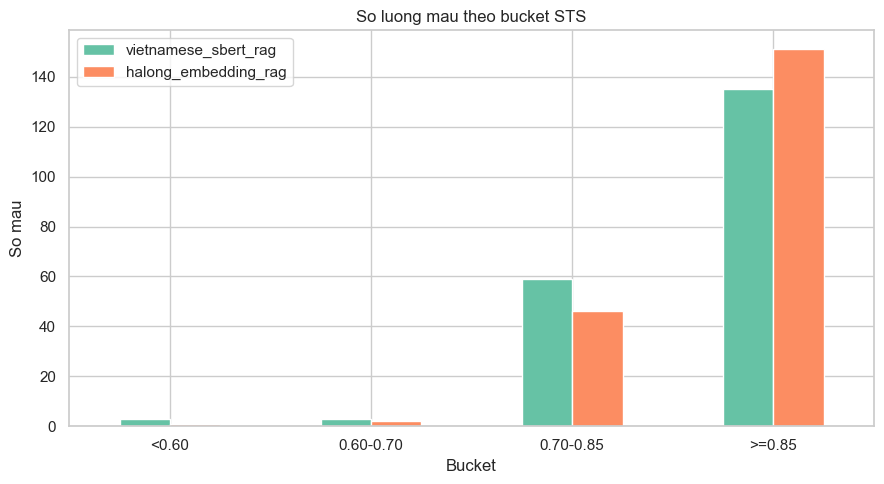

In [39]:
ax = bucket_df.plot(kind="bar", figsize=(9, 5), rot=0)
ax.set_title("So luong mau theo bucket STS")
ax.set_xlabel("Bucket")
ax.set_ylabel("So mau")
plt.tight_layout()
plt.show()

## Cac Mau Can Review

In [40]:
LOW_THRESHOLD = 0.70

review_cols = [
    "index",
    "sts_sbert",
    "sts_halong",
    "delta_halong_minus_sbert",
    "label_sbert",
    "label_halong",
    "instruction",
]

needs_review = df[(df["sts_sbert"] < LOW_THRESHOLD) | (df["sts_halong"] < LOW_THRESHOLD)].copy()
needs_review = needs_review.sort_values(["min_sts", "abs_delta"], ascending=[True, False])

print(f"So mau co it nhat mot diem STS < {LOW_THRESHOLD}: {len(needs_review)}")
display(needs_review[review_cols].head(25).style.format({
    "sts_sbert": "{:.4f}",
    "sts_halong": "{:.4f}",
    "delta_halong_minus_sbert": "{:.4f}",
}))

So mau co it nhat mot diem STS < 0.7: 8


,index,sts_sbert,sts_halong,delta_halong_minus_sbert,label_sbert,label_halong,instruction
189,190,0.5627,0.7648,0.2021,needs_review,acceptable,Điều 65 của Luật Địa chất và Khoáng sản đề cập đến việc khai thác những loại khoáng sản cụ thể nào?
135,136,0.5754,0.5860,0.0107,needs_review,needs_review,"Điều kiện tiên quyết để một tổ chức, cá nhân được phép chuyển nhượng quyền thăm dò khoáng sản là gì?"
118,119,0.5926,0.8786,0.2860,needs_review,good,Điều 40 quy định nghĩa vụ thông báo trước khi tiến hành khảo sát thực địa. Hãy cho biết nghĩa vụ này áp dụng cho những đối tượng nào và họ phải thông báo cho cơ quan nào?
51,52,0.6145,0.9618,0.3473,needs_review,good,"Theo Điều 17 của Luật Địa chất và Khoáng sản, nội dung điều tra địa chất công trình bao gồm những hoạt động nào?"
40,41,0.6272,0.8452,0.2180,needs_review,acceptable,Điều 14 phân định vai trò của Bộ Tài nguyên và Môi trường và Ủy ban nhân dân cấp tỉnh trong việc tổ chức thực hiện điều tra cơ bản địa chất như thế nào?
11,12,0.6362,0.9091,0.2729,needs_review,good,"Theo điểm đ khoản 2 Điều 4 của Luật Địa chất và Khoáng sản, tổ chức, cá nhân đang khai thác khoáng sản hợp pháp được ưu tiên thăm dò xuống sâu và mở rộng mà không phải đấu giá quyền khai thác khoáng sản trong điều kiện nào? Mục đích của quy định này là gì và cơ quan nào có trách nhiệm quy định chi tiết?"
31,32,0.7388,0.6422,-0.0966,acceptable,needs_review,Hãy giải thích ý nghĩa và tầm quan trọng của nguyên tắc được nêu tại khoản 3 Điều 12 liên quan đến việc quy hoạch các khu vực khoáng sản.
48,49,0.8831,0.6549,-0.2282,good,needs_review,"Theo Điều 18 khoản 1 Luật Địa chất và Khoáng sản, ""Điều tra điều kiện địa chất khác"" bao gồm những hoạt động nào?"


In [41]:
largest_gap = df.sort_values("abs_delta", ascending=False).copy()

print("Top mau co chenhlech diem lon nhat giua hai output RAG:")
display(largest_gap[review_cols].head(20).style.format({
    "sts_sbert": "{:.4f}",
    "sts_halong": "{:.4f}",
    "delta_halong_minus_sbert": "{:.4f}",
}))

Top mau co chenhlech diem lon nhat giua hai output RAG:


,index,sts_sbert,sts_halong,delta_halong_minus_sbert,label_sbert,label_halong,instruction
51,52,0.6145,0.9618,0.3473,needs_review,good,"Theo Điều 17 của Luật Địa chất và Khoáng sản, nội dung điều tra địa chất công trình bao gồm những hoạt động nào?"
118,119,0.5926,0.8786,0.2860,needs_review,good,Điều 40 quy định nghĩa vụ thông báo trước khi tiến hành khảo sát thực địa. Hãy cho biết nghĩa vụ này áp dụng cho những đối tượng nào và họ phải thông báo cho cơ quan nào?
11,12,0.6362,0.9091,0.2729,needs_review,good,"Theo điểm đ khoản 2 Điều 4 của Luật Địa chất và Khoáng sản, tổ chức, cá nhân đang khai thác khoáng sản hợp pháp được ưu tiên thăm dò xuống sâu và mở rộng mà không phải đấu giá quyền khai thác khoáng sản trong điều kiện nào? Mục đích của quy định này là gì và cơ quan nào có trách nhiệm quy định chi tiết?"
48,49,0.8831,0.6549,-0.2282,good,needs_review,"Theo Điều 18 khoản 1 Luật Địa chất và Khoáng sản, ""Điều tra điều kiện địa chất khác"" bao gồm những hoạt động nào?"
40,41,0.6272,0.8452,0.2180,needs_review,acceptable,Điều 14 phân định vai trò của Bộ Tài nguyên và Môi trường và Ủy ban nhân dân cấp tỉnh trong việc tổ chức thực hiện điều tra cơ bản địa chất như thế nào?
189,190,0.5627,0.7648,0.2021,needs_review,acceptable,Điều 65 của Luật Địa chất và Khoáng sản đề cập đến việc khai thác những loại khoáng sản cụ thể nào?
169,170,0.7058,0.8762,0.1705,acceptable,good,"Theo Khoản 2 Điều 57, Chính phủ có vai trò và trách nhiệm gì trong việc quy định chi tiết liên quan đến giấy phép khai thác khoáng sản?"
153,154,0.7287,0.8952,0.1664,acceptable,good,"Theo Điều 53 của Luật Địa chất và Khoáng sản, những loại hình tổ chức nào được xem xét cấp giấy phép khai thác khoáng sản?"
49,50,0.7411,0.9038,0.1628,acceptable,good,"Hãy so sánh mục đích và nội dung chính của việc ""Lập bản đồ không gian địa chất"" với ""Lập bản đồ không gian lòng đất"" theo quy định tại Điều 18."
68,69,0.7905,0.9386,0.1481,acceptable,good,"Công ty ABC Minerals đã tham gia điều tra địa chất về khoáng sản tại một khu vực nhất định và sau đó xác định được một mỏ khoáng sản tiềm năng. Theo Điều 22 của Luật này, Công ty ABC Minerals có những quyền lợi ưu tiên nào và nghĩa vụ chính của họ là gì nếu muốn tiếp tục thăm dò khoáng sản?"


## Xem Chi Tiet Mot Mau

In [42]:
# Doi SAMPLE_INDEX de xem chi tiet mau khac.
SAMPLE_INDEX = int(needs_review.iloc[0]["index"]) if not needs_review.empty else int(df.iloc[0]["index"])

sample = df.loc[df["index"] == SAMPLE_INDEX].iloc[0]

display(Markdown(f"### Mau #{SAMPLE_INDEX}"))
display(Markdown(f"**STS vietnamese-sbert RAG:** `{sample['sts_sbert']:.4f}`"))
display(Markdown(f"**STS halong_embedding RAG:** `{sample['sts_halong']:.4f}`"))
display(Markdown("#### Instruction"))
display(Markdown(str(sample["instruction"])))
display(Markdown("#### Reference response"))
display(Markdown(str(sample["response"])))
display(Markdown("#### qwen + RAG with vietnamese-sbert"))
display(Markdown(str(sample["sbert_answer"])))
display(Markdown("#### qwen + RAG with halong_embedding"))
display(Markdown(str(sample["halong_answer"])))

### Mau #190

**STS vietnamese-sbert RAG:** `0.5627`

**STS halong_embedding RAG:** `0.7648`

#### Instruction

Điều 65 của Luật Địa chất và Khoáng sản đề cập đến việc khai thác những loại khoáng sản cụ thể nào?

...

Điều 65 của Luật Địa chất và Khoáng sản quy định về việc khai thác các loại khoáng sản sau: khoáng sản chiến lược, khoáng sản quan trọng, khoáng sản độc hại và khoáng sản phóng xạ.

#### qwen + RAG with vietnamese-sbert

Kết luận ngắn: Tôi không tìm thấy căn cứ pháp lý đầy đủ trong dữ liệu được cung cấp.

Căn cứ pháp lý: CONTEXT không cung cấp thông tin về Điều 65 của Luật Địa chất và Khoáng sản 2024. Do đó, tôi không thể xác định loại khoáng sản cụ thể mà Điều 65 đề cập.

#### qwen + RAG with halong_embedding

Kết luận ngắn: Điều 65 của Luật Địa chất và Khoáng sản 2024 quy định về khai thác các loại khoáng sản chiến lược, quan trọng, độc hại và phóng xạ.

Căn cứ pháp lý:
- Luật Địa chất và Khoáng sản 2024, Số hiệu: 54/2024/QH15, Điều 65.

## Export Bang Phan Tich

In [43]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(REPORT_DIR / "sts_eval_items.csv", index=False, encoding="utf-8-sig")
metrics_df.to_csv(REPORT_DIR / "sts_eval_metrics.csv", encoding="utf-8-sig")
bucket_df.to_csv(REPORT_DIR / "sts_eval_buckets.csv", encoding="utf-8-sig")
needs_review.to_csv(REPORT_DIR / "sts_eval_needs_review.csv", index=False, encoding="utf-8-sig")

print(f"Da luu report vao: {REPORT_DIR}")

Da luu report vao: D:\dl\dl\data\processed\sts_eval_report
